# Notebook 4 — HOG + SVM Classification (4-class)

In [1]:
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report)
import joblib

RANDOM_STATE = 42
PROJECT_DIR   = Path.cwd().parent
PROCESSED_DIR = PROJECT_DIR / "outputs" / "processed_v2"
RESULTS_DIR   = PROJECT_DIR / "outputs" / "results_v2"
FIGURES_DIR   = PROJECT_DIR / "outputs" / "figures_v2"
MODELS_DIR    = PROJECT_DIR / "outputs" / "models_v2"
for d in [RESULTS_DIR, FIGURES_DIR, MODELS_DIR]: d.mkdir(parents=True, exist_ok=True)

CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

In [2]:
methods = ["raw", "ghe", "clahe"]
datasets = {}
for m in methods:
    d = np.load(PROCESSED_DIR / f"{m}_data.npz")
    datasets[m] = {k: d[k] for k in ["X_train","y_train","X_val","y_val","X_test","y_test"]}
    print(f"{m}: train={d['X_train'].shape}, test={d['X_test'].shape}")

raw: train=(5040, 128, 128, 1), test=(1080, 128, 128, 1)
ghe: train=(5040, 128, 128, 1), test=(1080, 128, 128, 1)
clahe: train=(5040, 128, 128, 1), test=(1080, 128, 128, 1)


In [3]:
def extract_hog_features(X):
    """Extract HOG features from a batch of (N, H, W, 1) images."""
    feats = []
    for img in X:
        f = hog(img[:,:,0], orientations=9, pixels_per_cell=(8,8),
                cells_per_block=(2,2), block_norm="L2-Hys")
        feats.append(f)
    return np.array(feats)

print("Extracting HOG features for all splits and methods (this takes a moment)...")
hog_data = {}
for m in methods:
    ds = datasets[m]
    hog_data[m] = {
        "X_train": extract_hog_features(ds["X_train"]),
        "y_train": ds["y_train"],
        "X_val":   extract_hog_features(ds["X_val"]),
        "y_val":   ds["y_val"],
        "X_test":  extract_hog_features(ds["X_test"]),
        "y_test":  ds["y_test"],
    }
    print(f"{m}: HOG feature dim = {hog_data[m]['X_train'].shape[1]}")

Extracting HOG features for all splits and methods (this takes a moment)...
raw: HOG feature dim = 8100
ghe: HOG feature dim = 8100
clahe: HOG feature dim = 8100


HOG+SVM on RAW
              precision    recall  f1-score   support

      glioma       0.95      0.91      0.93       270
  meningioma       0.90      0.93      0.91       270
     notumor       0.96      0.97      0.96       270
   pituitary       0.98      0.97      0.98       270

    accuracy                           0.95      1080
   macro avg       0.95      0.95      0.95      1080
weighted avg       0.95      0.95      0.95      1080



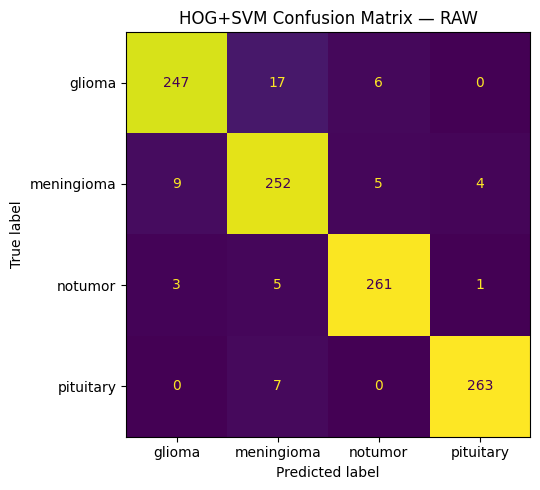

{'accuracy': 0.9472222222222222, 'precision': 0.9478418034510915, 'recall': 0.9472222222222222, 'f1_score': 0.9473331929646741, 'roc_auc': 0.995565843621399}
HOG+SVM on GHE
              precision    recall  f1-score   support

      glioma       0.95      0.91      0.93       270
  meningioma       0.89      0.93      0.91       270
     notumor       0.96      0.96      0.96       270
   pituitary       0.97      0.97      0.97       270

    accuracy                           0.94      1080
   macro avg       0.94      0.94      0.94      1080
weighted avg       0.94      0.94      0.94      1080



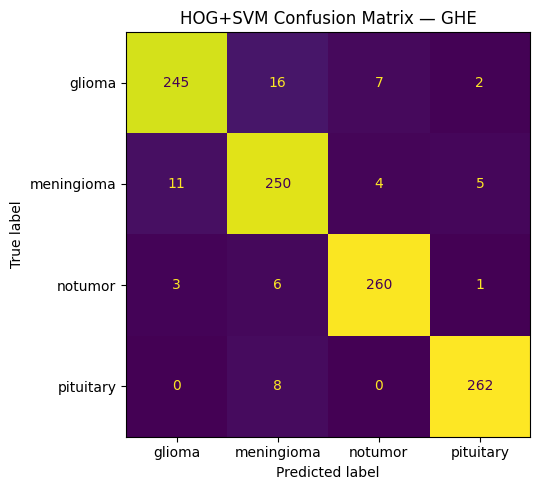

{'accuracy': 0.9416666666666667, 'precision': 0.94214576331735, 'recall': 0.9416666666666667, 'f1_score': 0.9417300665886391, 'roc_auc': 0.9940695016003658}
HOG+SVM on CLAHE
              precision    recall  f1-score   support

      glioma       0.95      0.92      0.94       270
  meningioma       0.90      0.94      0.92       270
     notumor       0.96      0.97      0.96       270
   pituitary       0.98      0.97      0.98       270

    accuracy                           0.95      1080
   macro avg       0.95      0.95      0.95      1080
weighted avg       0.95      0.95      0.95      1080



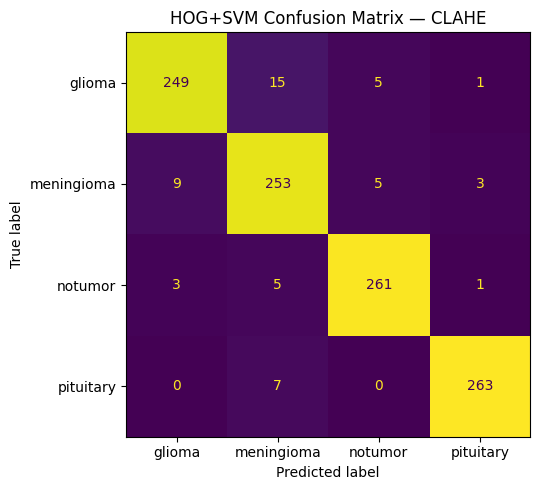

{'accuracy': 0.95, 'precision': 0.9505093329138938, 'recall': 0.95, 'f1_score': 0.9501070316891428, 'roc_auc': 0.9948205304069502}


In [4]:
def calc_metrics(y_true, y_prob, y_pred):
    try:
        auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except: auc = float("nan")
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_score":  f1_score(y_true, y_pred, average="macro", zero_division=0),
        "roc_auc":   auc,
    }

svm_results = []
for method in methods:
    print("="*60); print(f"HOG+SVM on {method.upper()}"); print("="*60)
    hd = hog_data[method]
    # Combine train+val for final SVM fit
    X_tr = np.vstack([hd["X_train"], hd["X_val"]])
    y_tr = np.concatenate([hd["y_train"], hd["y_val"]])
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    SVC(kernel="rbf", C=10, gamma="scale", probability=True,
                        random_state=RANDOM_STATE, decision_function_shape="ovr"))
    ])
    pipe.fit(X_tr, y_tr)
    y_prob = pipe.predict_proba(hd["X_test"])
    y_pred = y_prob.argmax(axis=1)
    metrics = calc_metrics(hd["y_test"], y_prob, y_pred)
    print(classification_report(hd["y_test"], y_pred, target_names=CLASSES))
    # Confusion matrix
    cm = confusion_matrix(hd["y_test"], y_pred)
    fig, ax = plt.subplots(figsize=(6,5))
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, values_format="d", colorbar=False)
    plt.title(f"HOG+SVM Confusion Matrix — {method.upper()}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"v2_hogsvm_{method}_confusion_matrix.png", dpi=150)
    plt.show()
    joblib.dump(pipe, MODELS_DIR / f"hog_svm_{method}.joblib")
    svm_results.append({"model":"HOG+SVM", "preprocessing":method, **metrics})
    print(metrics)

In [5]:
svm_df = pd.DataFrame(svm_results)
svm_df.to_csv(RESULTS_DIR / "hog_svm_results.csv", index=False)
print(svm_df.to_string(index=False))

  model preprocessing  accuracy  precision   recall  f1_score  roc_auc
HOG+SVM           raw  0.947222   0.947842 0.947222  0.947333 0.995566
HOG+SVM           ghe  0.941667   0.942146 0.941667  0.941730 0.994070
HOG+SVM         clahe  0.950000   0.950509 0.950000  0.950107 0.994821


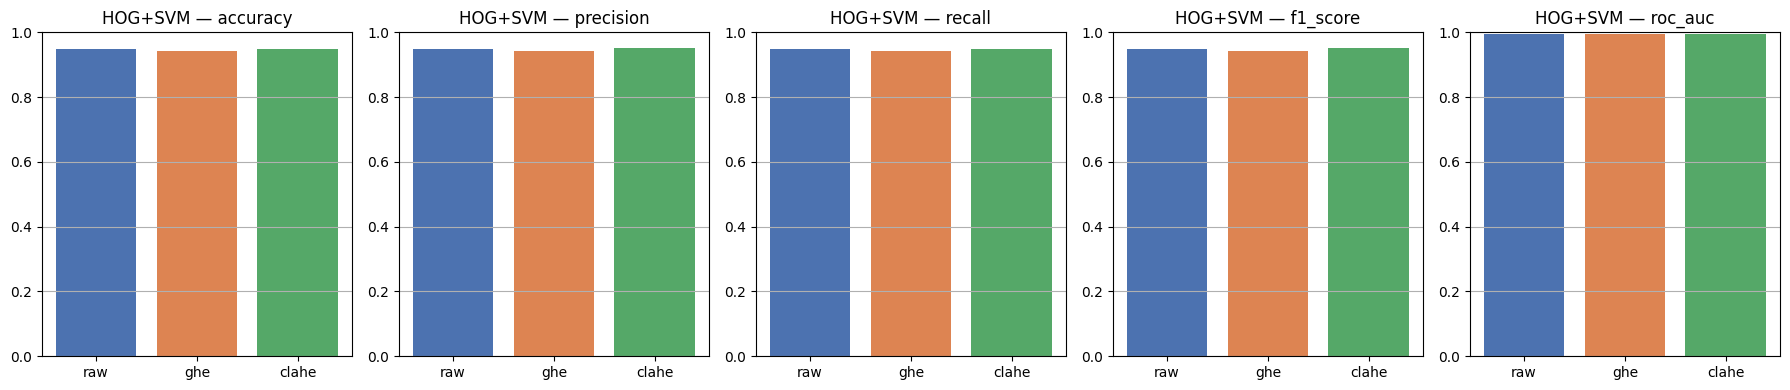

In [6]:
# Bar chart comparison
metrics_to_plot = ["accuracy","precision","recall","f1_score","roc_auc"]
fig, axes = plt.subplots(1, 5, figsize=(18,4))
for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(svm_df["preprocessing"], svm_df[metric], color=["#4C72B0","#DD8452","#55A868"])
    ax.set_title(f"HOG+SVM — {metric}"); ax.set_ylim(0,1); ax.grid(axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "v2_hogsvm_comparison.png", dpi=150)
plt.show()